=== 統計サマリー ===
[SA]
  成功率: 40.0%
  平均計算時間: 0.0080 sec
  平均FHT (FEs): 7614.9 ± 813.0
------------------------------
[ACO]
  成功率: 0.0%
  平均計算時間: 0.2298 sec
  平均FHT (FEs): nan ± nan
------------------------------


/tmp/ipykernel_725897/1420440632.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(labels)


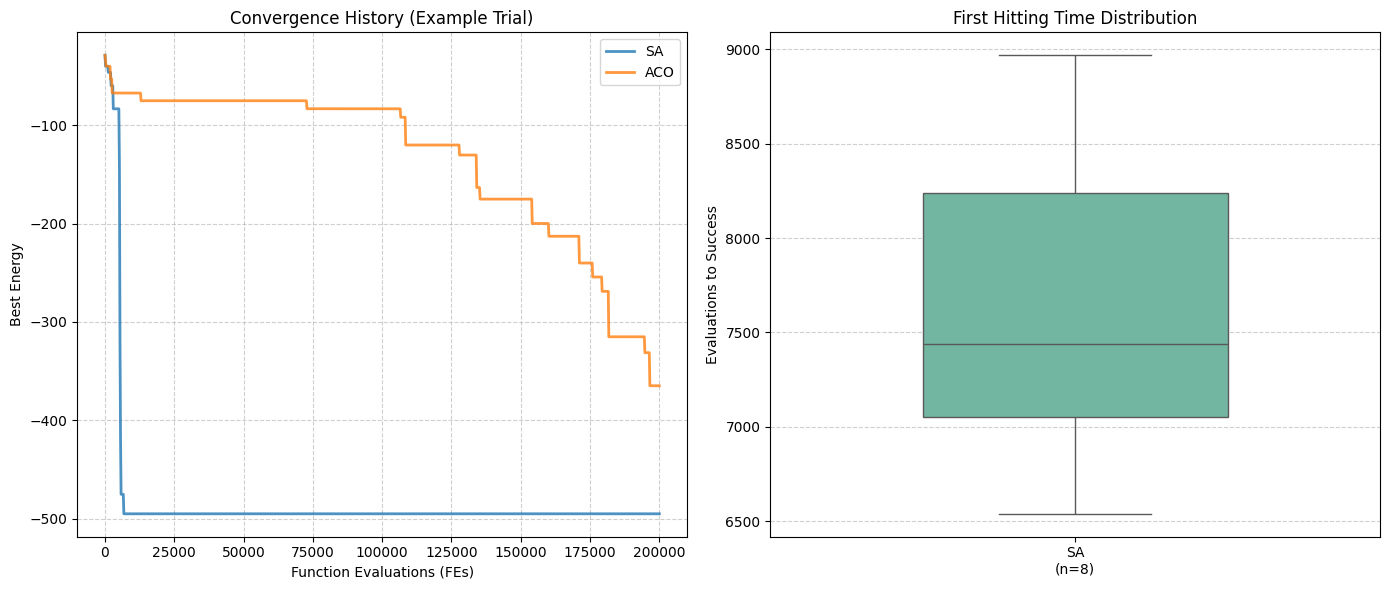

/tmp/ipykernel_725897/1420440632.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Method", y="WallClockTime", data=df_summary, palette="pastel", errorbar='sd')


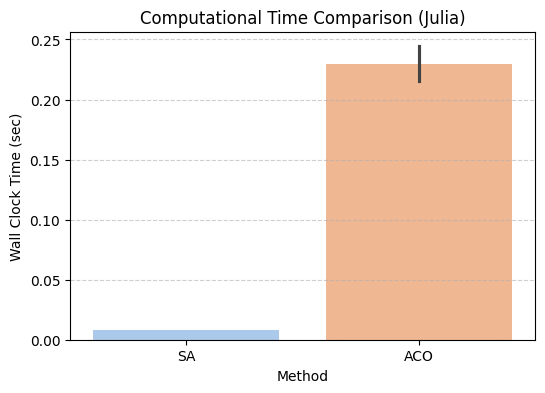

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. データの読み込み ---
df_summary = pd.read_csv("results_summary.csv")
df_hist_sa = pd.read_csv("history_sa.csv")
df_hist_aco = pd.read_csv("history_aco.csv")

# 文字列のNaNを正しく処理
df_summary["HittingTime"] = pd.to_numeric(df_summary["HittingTime"], errors='coerce')

# --- 2. 統計量の表示 ---
print("=== 統計サマリー ===")
methods = df_summary["Method"].unique()
for m in methods:
    sub = df_summary[df_summary["Method"] == m]
    success_rate = sub["Success"].mean() * 100
    avg_time = sub["WallClockTime"].mean()
    # 成功した試行のみでHitting Timeを計算
    success_sub = sub[sub["Success"] == True]
    avg_hit = success_sub["HittingTime"].mean() if not success_sub.empty else np.nan
    std_hit = success_sub["HittingTime"].std() if not success_sub.empty else np.nan
    
    print(f"[{m}]")
    print(f"  成功率: {success_rate:.1f}%")
    print(f"  平均計算時間: {avg_time:.4f} sec")
    print(f"  平均FHT (FEs): {avg_hit:.1f} ± {std_hit:.1f}")
    print("-" * 30)

# --- 3. プロット作成 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (A) 収束履歴 (Convergence History)
# ※間引かれたデータなので、実際のFEsに変換してプロット（簡易的）
# historyファイルは最後の1試行のみ
max_fes = 200000
steps_sa = np.linspace(0, max_fes, len(df_hist_sa))
steps_aco = np.linspace(0, max_fes, len(df_hist_aco))

axes[0].plot(steps_sa, df_hist_sa["BestEnergy"], label="SA", linewidth=2, alpha=0.8)
axes[0].plot(steps_aco, df_hist_aco["BestEnergy"], label="ACO", linewidth=2, alpha=0.8)
axes[0].set_xlabel("Function Evaluations (FEs)")
axes[0].set_ylabel("Best Energy")
axes[0].set_title("Convergence History (Example Trial)")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# (B) First Hitting Time (FHT) の分布
# 成功した試行のHittingTimeのみを抽出
data_sa = df_summary[(df_summary["Method"] == "SA") & (df_summary["Success"] == True)]["HittingTime"]
data_aco = df_summary[(df_summary["Method"] == "ACO") & (df_summary["Success"] == True)]["HittingTime"]

data_to_plot = []
labels = []
if len(data_sa) > 0:
    data_to_plot.append(data_sa)
    labels.append(f"SA\n(n={len(data_sa)})")
if len(data_aco) > 0:
    data_to_plot.append(data_aco)
    labels.append(f"ACO\n(n={len(data_aco)})")

if data_to_plot:
    sns.boxplot(data=data_to_plot, ax=axes[1], width=0.5, palette="Set2")
    axes[1].set_xticklabels(labels)
    axes[1].set_ylabel("Evaluations to Success")
    axes[1].set_title("First Hitting Time Distribution")
    axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)
else:
    axes[1].text(0.5, 0.5, "No Success Trials", ha='center')

plt.tight_layout()
plt.show()

# (C) 実計算時間の比較
plt.figure(figsize=(6, 4))
sns.barplot(x="Method", y="WallClockTime", data=df_summary, palette="pastel", errorbar='sd')
plt.ylabel("Wall Clock Time (sec)")
plt.title("Computational Time Comparison (Julia)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()